In [7]:
import numpy as np
import pandas as pd

np.random.seed(23)

# Class 1
mu_vec1 = np.array([0, 0, 0])

cov_mat1 = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
])

class1_sample = np.random.multivariate_normal(
    mu_vec1,
    cov_mat1,
    20
)

df = pd.DataFrame(
    class1_sample,
    columns=['feature1', 'feature2', 'feature3']
)

df['target'] = 1


# Class 2
mu_vec2 = np.array([1, 1, 1])

cov_mat2 = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
])

class2_sample = np.random.multivariate_normal(
    mu_vec2,
    cov_mat2,
    20
)

df1 = pd.DataFrame(
    class2_sample,
    columns=['feature1', 'feature2', 'feature3']
)

df1['target'] = 0


# Combine datasets
df = pd.concat([df, df1], ignore_index=True)

# Shuffle
df = df.sample(40, random_state=23).reset_index(drop=True)

df.head()

,feature1,feature2,feature3,target
0,-0.331617,-1.632386,0.619114,1
1,1.010229,1.437830,2.327788,0
2,0.241106,-0.952510,-0.136267,1
3,1.676860,4.187503,-0.080565,0
4,2.823378,-0.332863,2.637391,0


In [8]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='feature1',
    y='feature2',
    z='feature3',
    color=df['target'].astype(str)
)

fig.update_traces(
    marker=dict(
        size=12,
        line=dict(
            width=2,
            color='DarkSlateGrey'
        )
    )
)

fig.show()

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df.iloc[:, 0:3] = scaler.fit_transform(
    df.iloc[:, 0:3]
)

In [10]:
covariance_matrix = np.cov(
    [
        df.iloc[:, 0],
        df.iloc[:, 1],
        df.iloc[:, 2]
    ]
)

print("Covariance Matrix:\n", covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [11]:
eigen_values, eigen_vectors = np.linalg.eig(
    covariance_matrix
)

print("Eigenvalues:")
print(eigen_values)

print("\nEigenvectors:")
print(eigen_vectors)

Eigenvalues:
[1.3536065  0.94557084 0.77774573]

Eigenvectors:
[[-0.53875915 -0.69363291  0.47813384]
 [-0.65608325 -0.01057596 -0.75461442]
 [-0.52848211  0.72025103  0.44938304]]


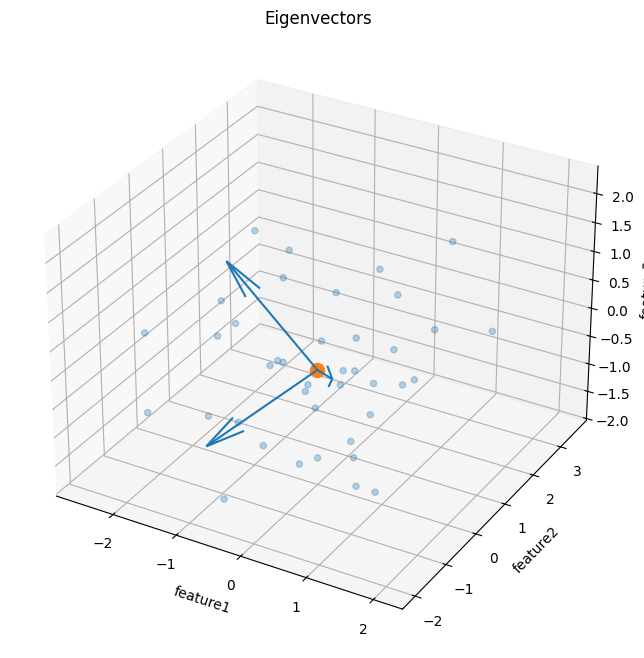

In [12]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot data points
ax.scatter(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    alpha=0.3
)

# Mean point
mean_x = df['feature1'].mean()
mean_y = df['feature2'].mean()
mean_z = df['feature3'].mean()

ax.scatter(
    mean_x,
    mean_y,
    mean_z,
    s=100
)

# Eigenvectors
for v in eigen_vectors.T:

    ax.quiver(
        mean_x,
        mean_y,
        mean_z,
        v[0],
        v[1],
        v[2],
        length=2,
        normalize=True
    )

ax.set_xlabel('feature1')
ax.set_ylabel('feature2')
ax.set_zlabel('feature3')

plt.title('Eigenvectors')

plt.show()

In [16]:
idx = np.argsort(eigen_values)[::-1]

eigen_values = eigen_values[idx]
eigen_vectors = eigen_vectors[:, idx]

pc = eigen_vectors[:, 0:2]

print("Principal Components:")
print(pc)

Principal Components:
[[-0.53875915 -0.69363291]
 [-0.65608325 -0.01057596]
 [-0.52848211  0.72025103]]


In [17]:
transformed_df = np.dot(
    df.iloc[:, 0:3],
    pc
)

new_df = pd.DataFrame(
    transformed_df,
    columns=['PC1', 'PC2']
)

new_df['target'] = df['target'].values

new_df.head()

,PC1,PC2,target
0,1.694055,0.454694,1
1,-1.654764,0.691473,0
2,1.349328,-0.377883,1
3,-2.572050,-1.265530,0
4,-1.544065,-0.194608,0


In [18]:
new_df['target'] = new_df['target'].astype(str)

fig = px.scatter(
    new_df,
    x='PC1',
    y='PC2',
    color='target',
    color_discrete_sequence=px.colors.qualitative.G10
)

fig.update_traces(
    marker=dict(
        size=12,
        line=dict(
            width=2,
            color='DarkSlateGrey'
        )
    )
)

fig.show()